# Used Car Price Prediction

## Problem statement.

* This dataset comprises of used cars sold on cardekho.com in India as well as important features of these cars.
* User can predict the price of the car based on input features.
* Prediction results can be used to give new seller the price suggestion based on market condition.

## Importing Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

## Load Dataset

In [37]:
df = pd.read_csv("data/cardekho_dataset.csv", index_col=[0])

In [38]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Shape and structure

In [39]:
df.shape

(15411, 13)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [41]:
df.duplicated().sum()

np.int64(167)

In [42]:
df = df.drop_duplicates()
df.shape

(15244, 13)

### Remove Unnecessary Columns

In [44]:
df['car_name'].nunique(), df['model'].nunique(), df['brand'].nunique()

(121, 120, 32)

In [45]:

df.drop('car_name', axis=1, inplace=True)
df.drop('brand', axis=1, inplace=True)

In [46]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# Target Variable Analysis

## Distribution and Outliers

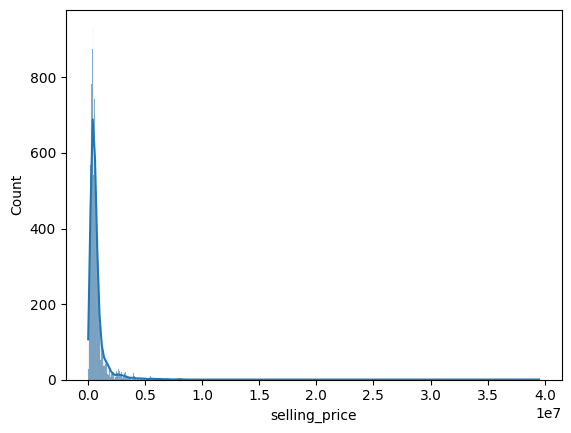

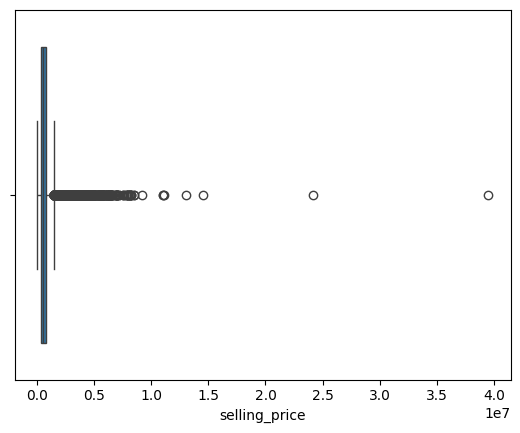

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['selling_price'], kde=True)
plt.show()

sns.boxplot(x=df['selling_price'])
plt.show()

## Observations

* The target variable is right-skewed
* Presence of high-value outliers is expected in car pricing

# Numerical Feature Analysis

## Correlation with Target

In [48]:
num_cols = [
    'vehicle_age','km_driven','mileage',
    'engine','max_power','seats'
]

df[num_cols + ['selling_price']].corr()['selling_price'].sort_values(ascending=False)

selling_price    1.000000
max_power        0.751058
engine           0.585713
seats            0.115299
km_driven       -0.079548
vehicle_age     -0.241228
mileage         -0.305128
Name: selling_price, dtype: float64

## Observations

* engine and max_power show strong positive correlation
* vehicle_age and km_driven negatively impact price
* seats has limited but meaningful influenc

# Outlier Check

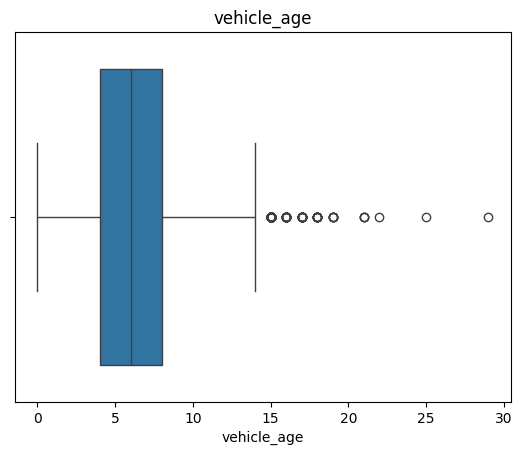

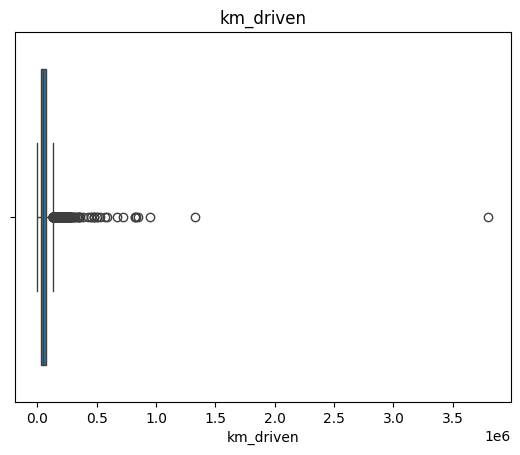

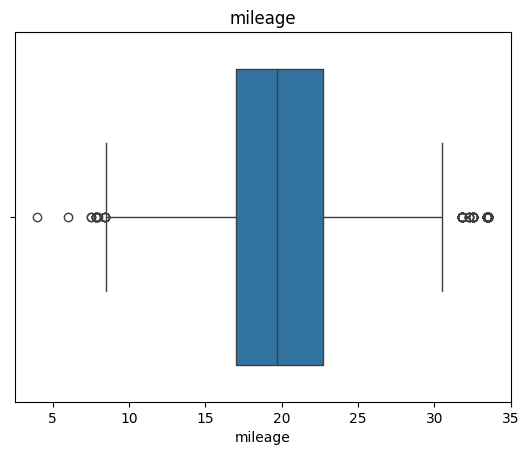

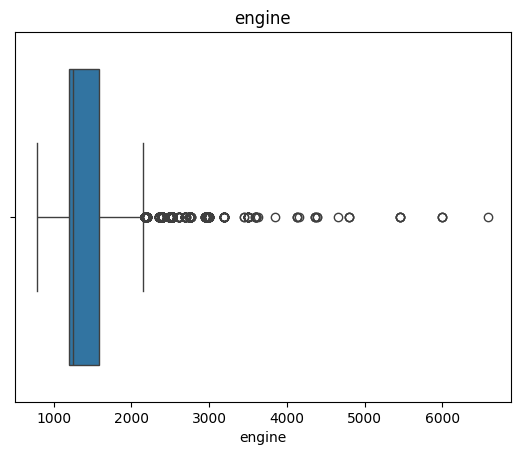

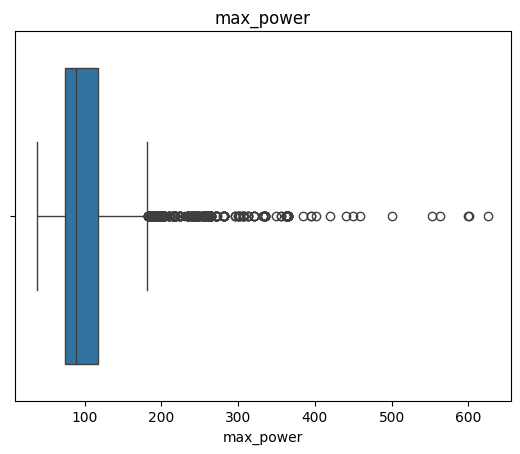

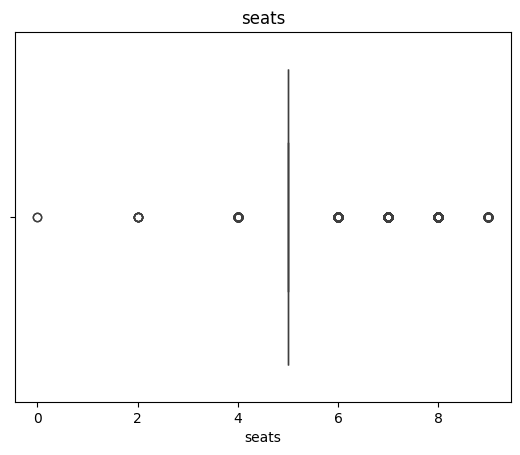

In [49]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Price Impact Visualization

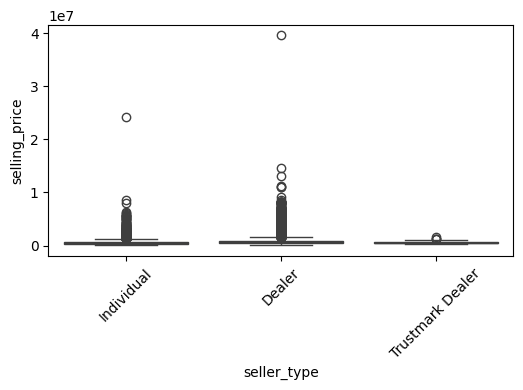

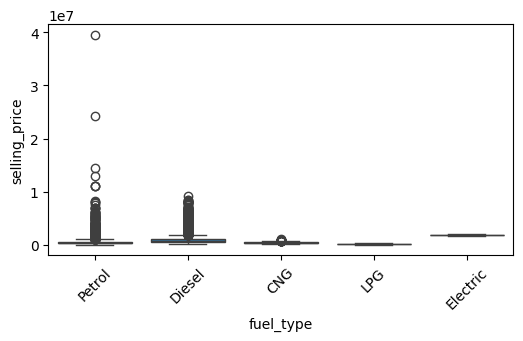

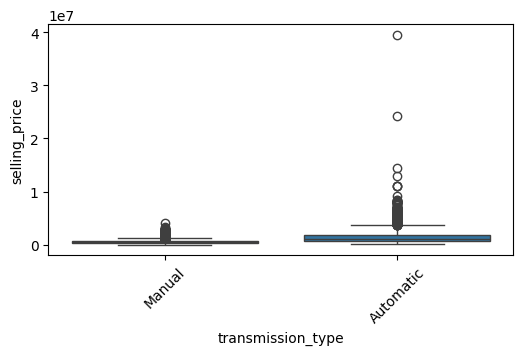

In [50]:
cat_cols = [
    'seller_type',
    'fuel_type','transmission_type'
]

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=col, y='selling_price', data=df)
    plt.xticks(rotation=45)
    plt.show()